In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from diptest import diptest
from binning import *

In [2]:
"""
We assume that the spot coordinates (avaiable with the datasets) are in um unit.
"""

'\nWe assume that the spot coordinates (avaiable with the datasets) are in um unit.\n'

### Merfish Lung Cancer

In [3]:

path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_Breast_Cancer/ST/"

unbinned_st_path = path + "unbinned_ST/ST_with_annotations.h5ad"

binned_path = path + "ST_55_python.h5ad"

dataset =  "merfish_breast_cancer"
celltype_col = "celltype"
spot_diameter = 55 #55 # 550 -> 510 # 100->6, 9, etc.
coord1 = 0
coord2 = 1

combined_adata = binning(unbinned_st_path, spot_diameter, celltype_col, dataset, coord1, coord2)
print (combined_adata)

merfish_breast_cancer
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 1
Number of spots in mask: 2
Number of spots in mask: 5
Number of spots in mask: 4
Number of spots in mask: 4
Number of spots in mask: 5
Number of spots in mask: 6
Number of spots in mask: 6
Number of spots in mask: 7
Number of spots in mask: 8
Number of spots in mask: 6
Number of spots in mask: 5
Number of spots in mask: 8
Number of spots in mask: 11
Number of spots in mask: 8
Number of spots in mask: 9
Number of spots in mask: 9
Number of spots in mask: 9
Number of spots in mask: 11
Number of spots in mask: 14
Number of spots in mask: 14
Number of spots in mask: 18
Number of spots in mask: 11
Number of spots in mask: 16
Number of spots in mask: 14
Number of spots in mask: 13
Number of spots in mask: 11
Number of spots in mask: 19
Number of spots in mask: 17
Number of spots in mask: 12
Number of spots in mask: 15
Number of spots in 

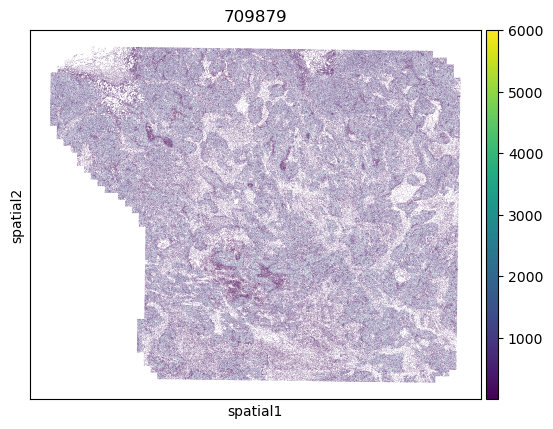

In [4]:
st_adata = sc.read_h5ad(unbinned_st_path)
st_adata.obsm["spatial"] = st_adata.obsm["spatial"].to_numpy()
st_adata.obs["umi_count"] = st_adata.X.sum(axis = 1)
sc.pl.embedding(st_adata, basis = "spatial", color = "umi_count", title = st_adata.shape)

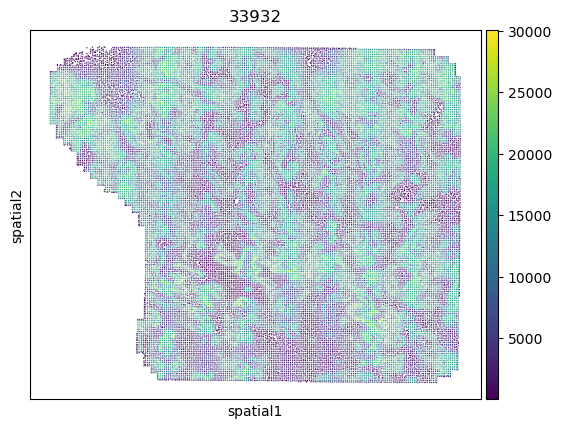

In [5]:
combined_adata.obs["umi_count"] = combined_adata.X.sum(axis = 1)
sc.pl.embedding(combined_adata, basis = "spatial", color = "umi_count", title = combined_adata.shape)

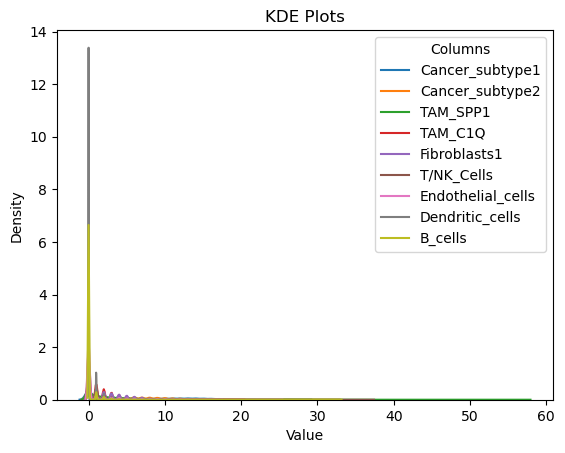

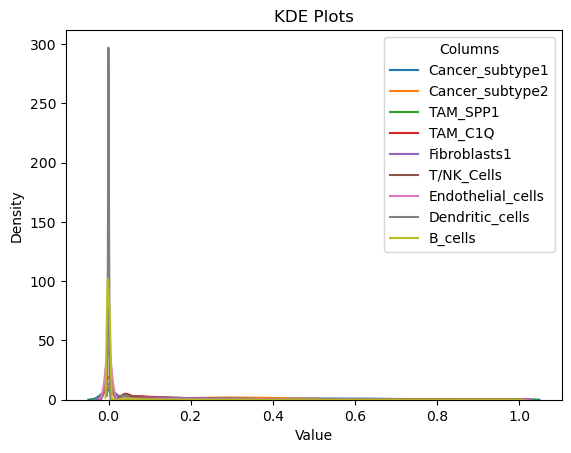

In [6]:
dt = combined_adata.obs
dt = dt[dt.columns[:-2]]
dt_ = dt.div(dt.sum(axis=1),axis=0)
diptest(dt)
diptest(dt_)

In [7]:
dt = dt.sort_index(axis=1)

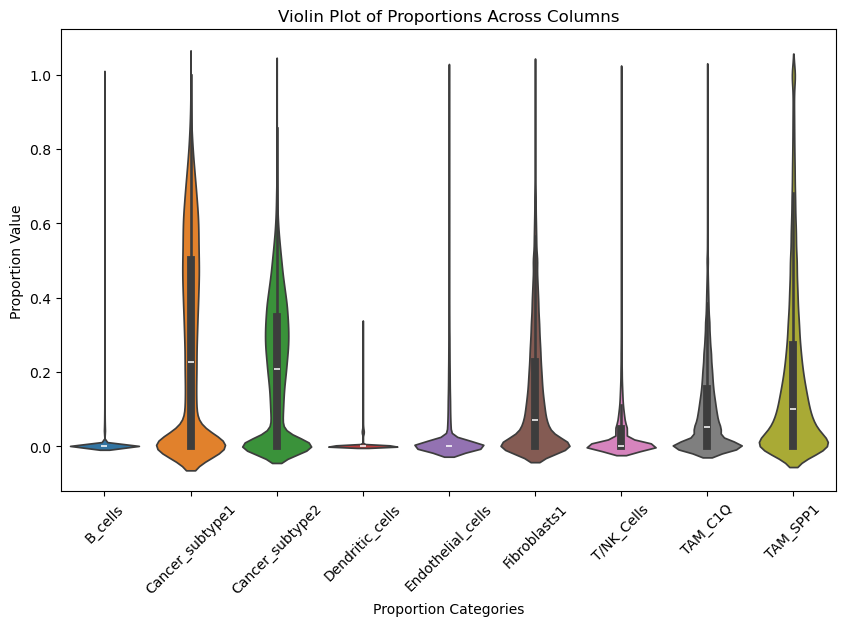

In [8]:
dt_ = dt_.sort_index(axis=1)

# Violin plot for more detailed distribution visualization
plt.figure(figsize=(10, 6))
sns.violinplot(data=dt_)
plt.title('Violin Plot of Proportions Across Columns')
plt.ylabel('Proportion Value')
plt.xlabel('Proportion Categories')
plt.xticks(rotation=45) #after creating the plot. Here's how you can adjust the code:
plt.show()

In [9]:
dt_

,B_cells,Cancer_subtype1,Cancer_subtype2,Dendritic_cells,Endothelial_cells,Fibroblasts1,T/NK_Cells,TAM_C1Q,TAM_SPP1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


(array([1.000e+02, 1.070e+02, 0.000e+00, 1.550e+02, 2.050e+02, 0.000e+00,
        2.870e+02, 0.000e+00, 3.560e+02, 4.190e+02, 0.000e+00, 5.430e+02,
        0.000e+00, 6.340e+02, 6.580e+02, 0.000e+00, 7.620e+02, 8.000e+02,
        0.000e+00, 8.720e+02, 0.000e+00, 9.830e+02, 1.027e+03, 0.000e+00,
        1.169e+03, 0.000e+00, 1.202e+03, 1.348e+03, 0.000e+00, 1.567e+03,
        1.735e+03, 0.000e+00, 1.842e+03, 0.000e+00, 1.991e+03, 1.944e+03,
        0.000e+00, 2.031e+03, 0.000e+00, 1.949e+03, 1.748e+03, 0.000e+00,
        1.535e+03, 1.325e+03, 0.000e+00, 1.006e+03, 0.000e+00, 9.130e+02,
        6.420e+02, 0.000e+00, 5.500e+02, 0.000e+00, 3.650e+02, 2.900e+02,
        0.000e+00, 2.140e+02, 1.660e+02, 0.000e+00, 1.110e+02, 0.000e+00,
        9.900e+01, 6.800e+01, 0.000e+00, 4.900e+01, 0.000e+00, 4.100e+01,
        2.500e+01, 0.000e+00, 1.000e+01, 2.300e+01, 0.000e+00, 2.200e+01,
        0.000e+00, 9.000e+00, 9.000e+00, 0.000e+00, 6.000e+00, 0.000e+00,
        7.000e+00, 6.000e+00, 0.000e+0

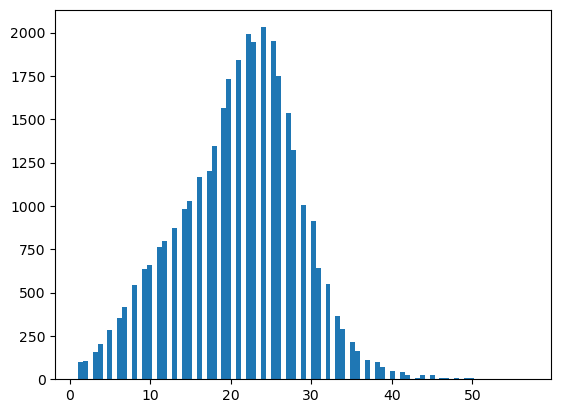

In [10]:
a = dt.sum(axis = 1)
plt.hist(a, bins='auto')

In [11]:
combined_adata.write_h5ad(binned_path)
no_of_cells = dt.sum(axis = 1)
no_of_cells.to_csv(path + "no_of_cells.csv")

res_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_Breast_Cancer/final_outputs_repo/gt.h5ad"

columns = combined_adata.obs.columns.tolist()[:-2]
loc = combined_adata.obsm["spatial"]#.to_numpy()
columns.sort()

ann_test = anndata.AnnData(dt_.to_numpy())
ann_test.obsm["Average_STAGATE_ReX"] = dt_.to_numpy()
ann_test.var_names = columns
ann_test.obsm["spatial"] = loc

print (ann_test)    
ann_test.write_h5ad(res_path)  


AnnData object with n_obs × n_vars = 33932 × 9
    obsm: 'Average_STAGATE_ReX', 'spatial'


In [12]:
combined_adata.var_names = st_adata.var_names
combined_adata.obs_names = [str(i) for i in range(len(combined_adata))]
print (combined_adata.obs_names, combined_adata.var_names)
combined_adata.write_h5ad(binned_path)

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '33922', '33923', '33924', '33925', '33926', '33927', '33928', '33929',
       '33930', '33931'],
      dtype='object', length=33932) Index(['PDK4', 'CCL26', 'CX3CL1', 'PGLYRP1', 'CD4', 'SNAI2', 'TNFRSF17',
       'ICAM3', 'TBX21', 'FAP',
       ...
       'PDPN', 'IL4', 'TRBC1', 'SERPINA1', 'FGFR2', 'ATM', 'PRF1', 'IL10',
       'IL17A', 'NOTCH1'],
      dtype='object', length=500)


In [13]:
combined_adata

AnnData object with n_obs × n_vars = 33932 × 500
    obs: 'Cancer_subtype1', 'Cancer_subtype2', 'TAM_SPP1', 'TAM_C1Q', 'Fibroblasts1', 'T/NK_Cells', 'Endothelial_cells', 'Dendritic_cells', 'B_cells', 'dataset', 'umi_count'
    obsm: 'spatial'